#***Libraries***

In [1]:
import os
import numpy as np
import kagglehub
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from collections import Counter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

#***Download Data***


In [2]:
# Install the Kaggle Hub package to download datasets
!pip install kagglehub -q

# Download the TrashNet dataset from Kaggle
path = kagglehub.dataset_download("feyzazkefe/trashnet")

# Print the path where the dataset is saved on the computer
print("Path:", path)

Using Colab cache for faster access to the 'trashnet' dataset.
Path: /kaggle/input/trashnet


#***Data Exploration***

In [3]:
# Path to the main TrashNet dataset folder
dataset_path = os.path.join(path, "dataset-resized")

# 1st, show what is inside the main folder
print("Contents of main folder:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f"  Folder: {item} - {count} images")
    else:
        print(f"  File: {item}")


Contents of main folder:
  Folder: metal - 410 images
  Folder: glass - 501 images
  Folder: paper - 594 images
  Folder: trash - 137 images
  Folder: cardboard - 403 images
  Folder: plastic - 482 images


#***Data Pre-processing***

In [4]:
classes = ["glass", "paper", "cardboard", "plastic", "metal", "trash"]

images = []
labels = []

# Load original images
for idx, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    count = 0
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        # Resize to 224x224 and normalize pixel values to [0,1]
        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img = tf.keras.utils.img_to_array(img) / 255.0
        images.append(img)
        labels.append(idx)
        count += 1
    print(f"{cls}: {count} images")

glass: 501 images
paper: 594 images
cardboard: 403 images
plastic: 482 images
metal: 410 images
trash: 137 images


In [5]:
# Calculate class weights for imbalance handling
print("\nCalculating class weights to deal with imbalance data ")
class_counts = Counter(labels)
total_samples = len(labels)
n_classes = len(classes)

class_weights_dict = {}
for class_idx in range(n_classes):
    count = class_counts.get(class_idx, 1)
    weight = total_samples / (n_classes * count)
    class_weights_dict[class_idx] = weight

print("Class weights:")
for idx, cls in enumerate(classes):
    if idx in class_weights_dict:
        print(f"  {cls}: {class_weights_dict[idx]:.3f}")


Calculating class weights to deal with imbalance data 
Class weights:
  glass: 0.841
  paper: 0.709
  cardboard: 1.045
  plastic: 0.874
  metal: 1.027
  trash: 3.074


In [6]:
# Data augmentation pipeline (flip, rotation, brightness)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# Target count per class to reduce imbalance (at least 450 images)
target_counts = {"cardboard": 450, "metal": 450, "trash": 450}
# Apply augmentation only to underrepresented classes
for cls_name, target in target_counts.items():
    cls_idx = classes.index(cls_name)
    cls_images = [img for img, lbl in zip(images, labels) if lbl == cls_idx]
    current = len(cls_images)
    needed = target - current

    if needed > 0:
        aug_per_image = needed // current + 1  # How many augmented copies per image
        for img in cls_images:
            if needed <= 0:
                break
            img_batch = np.expand_dims(img, 0)
            for _ in range(aug_per_image):
                if needed <= 0:
                    break
                aug_img = augment(img_batch, training=True)[0].numpy()
                images.append(aug_img)
                labels.append(cls_idx)
                needed -= 1

# Count final distribution
final_counts = Counter(labels)
for i, cls in enumerate(classes):
    print(f"{cls}: {final_counts[i]} images (original + augmented)")

X = np.array(images)
y = tf.keras.utils.to_categorical(labels, num_classes=6)  # One-hot encode labels

glass: 501 images (original + augmented)
paper: 594 images (original + augmented)
cardboard: 450 images (original + augmented)
plastic: 482 images (original + augmented)
metal: 450 images (original + augmented)
trash: 450 images (original + augmented)


In [7]:
# Split data: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # Preserve class distribution
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print("Done Pre-processing.")


Train: 2048 | Validation: 439 | Test: 440
Done Pre-processing.


#***Training MobileNet V2***

In [8]:
# Load MobileNetV2 pre-trained on ImageNet (without top classification layer)
base_model_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_mobilenet.trainable = False  # Freeze the base model weights

# Build the full model
model = Sequential([
    base_model_mobilenet,
    GlobalAveragePooling2D(),     # Convert feature maps to a single vector
    tf.keras.layers.BatchNormalization(), # Maintain the mean output close to 0 and the output standard deviation close to 1
    Dense(512, activation='relu'),
    Dropout(0.5),                 # Dropout to prevent overfitting
    Dense(256, activation='relu'),  # Additional layer
    Dropout(0.3),                 # Dropout ...
    Dense(6, activation='softmax') # Output layer for 6 classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Training ")
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=32,
                    verbose=1)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training 
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - accuracy: 0.6099 - loss: 1.1905 - val_accuracy: 0.7198 - val_loss: 0.6677
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7749 - loss: 0.6762 - val_accuracy: 0.8041 - val_loss: 0.5707
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8174 - loss: 0.5165 - val_accuracy: 0.8155 - val_loss: 0.5421
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8599 - loss: 0.4056 - val_accuracy: 0.8064 - val_loss: 0.5281
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8818 - loss: 0.3344 - val_accuracy: 0.8178 - val_loss: 0.5230
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8960 - loss: 0.3067 - val_accuracy: 0.8200 - val_loss: 0.5092
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9009 - loss: 0.3078 - val_accuracy: 0.8178 - val_loss: 0.5537
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step

# ***Evaluation and Visualization MobileNet V2***

Test Accuracy: 82.05%


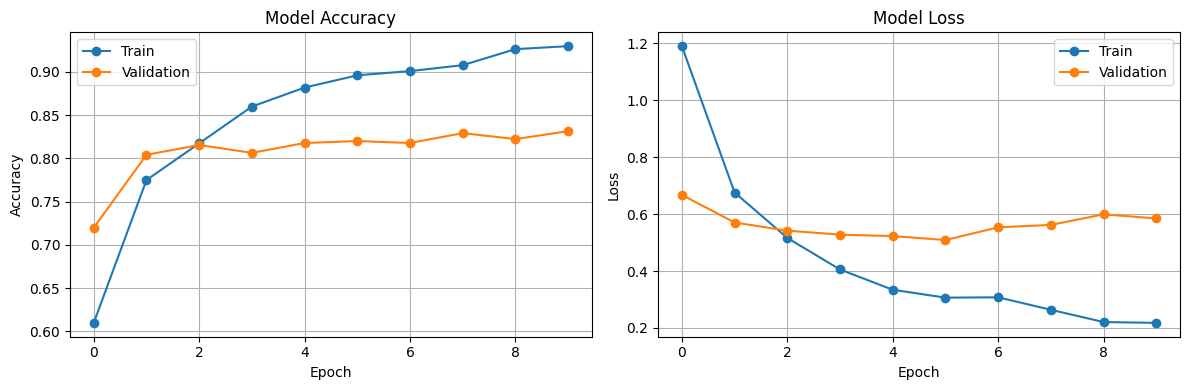

In [9]:
# Class names in order
classes = ["glass", "paper", "cardboard", "plastic", "metal", "trash"]

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train', marker='o')
plt.plot(history.history['val_loss'], label='Validation', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Predict on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)    # Convert probabilities to class index
y_true_classes = np.argmax(y_test, axis=1)   # Convert one-hot to class index


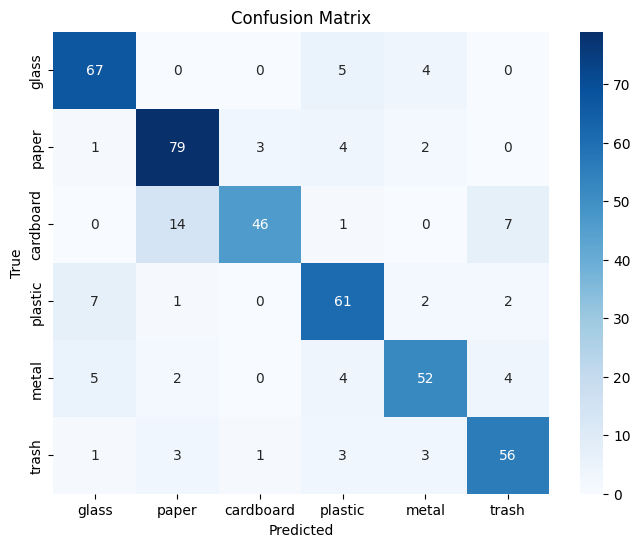

Classification Report:
              precision    recall  f1-score   support

       glass       0.83      0.88      0.85        76
       paper       0.80      0.89      0.84        89
   cardboard       0.92      0.68      0.78        68
     plastic       0.78      0.84      0.81        73
       metal       0.83      0.78      0.80        67
       trash       0.81      0.84      0.82        67

    accuracy                           0.82       440
   macro avg       0.83      0.82      0.82       440
weighted avg       0.83      0.82      0.82       440



In [10]:
# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print precision, recall, and F1-score for each class
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes, zero_division=0))

# **Training EfficientNet**

In [11]:
# Load EfficientNet pre-trained on ImageNet (without top classification layer)
base_model_efficient = tf.keras.applications.EfficientNetV2B0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_efficient.trainable = False  # Freeze the base model weights

# Build the full model with EfficientNetV2B0 as the base
model_efficient = Sequential([
    base_model_efficient,
    GlobalAveragePooling2D(),     # Convert feature maps to a single vector
    tf.keras.layers.BatchNormalization(), # Maintain the mean output close to 0 and the output standard deviation close to 1
    Dense(512, activation='relu'),
    Dropout(0.5),                 # Dropout to prevent overfitting
    Dense(256, activation='relu'),  # Additional layer
    Dropout(0.3),                 # Dropout ...
    Dense(6, activation='softmax') # Output layer for 6 classes
])

# Compile the model
model_efficient.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Training EfficientNetV2B0...")
history_efficient = model_efficient.fit(X_train, y_train,
                                        validation_data=(X_val, y_val),
                                        epochs=10,
                                        batch_size=32,
                                        verbose=1)
print("Done training EfficientNetV2B0.")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training EfficientNetV2B0...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 280ms/step - accuracy: 0.2173 - loss: 2.1962 - val_accuracy: 0.1868 - val_loss: 1.7852
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.2280 - loss: 1.9226 - val_accuracy: 0.1936 - val_loss: 1.7834
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.2251 - loss: 1.8191 - val_accuracy: 0.2711 - val_loss: 1.7790
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2300 - loss: 1.8033 - val_accuracy: 0.3030 - val_loss: 1.7676
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.2334 - loss: 1.7525 - val_accuracy: 0.3098 - val_loss: 1.7505
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2437 - loss: 1.7537 - val_accuracy: 0.3144 - val_loss: 1.7369
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2368 - loss: 1.7364 - val_accuracy: 0.3007 - val_loss: 1.7160
Epoch 8/10
64/64 ━━━━━━━━━━━━

#**Evaluation and Visualization EfficientNet**

EfficientNet Test Accuracy: 35.45%


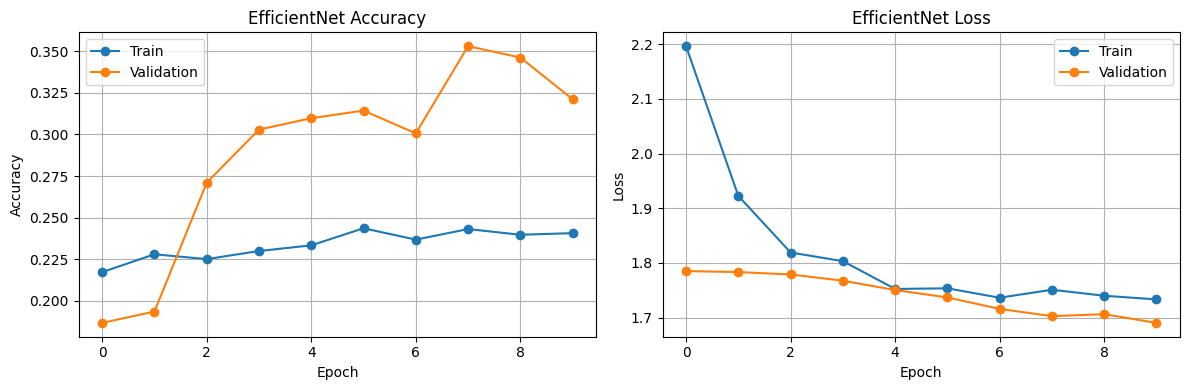

In [12]:
# Evaluate the EfficientNet on the test set
test_loss_efficient, test_acc_efficient = model_efficient.evaluate(X_test, y_test, verbose=0)
print(f"EfficientNet Test Accuracy: {test_acc_efficient*100:.2f}%")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_efficient.history['accuracy'], label='Train', marker='o')
plt.plot(history_efficient.history['val_accuracy'], label='Validation', marker='o')
plt.title('EfficientNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_efficient.history['loss'], label='Train', marker='o')
plt.plot(history_efficient.history['val_loss'], label='Validation', marker='o')
plt.title('EfficientNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#  Predict on test set
y_pred_efficient = model_efficient.predict(X_test, verbose=0)
y_pred_classes_efficient = np.argmax(y_pred_efficient, axis=1)    # Convert probabilities to class index
y_true_classes_efficient = np.argmax(y_test, axis=1)   # Convert one-hot to class index

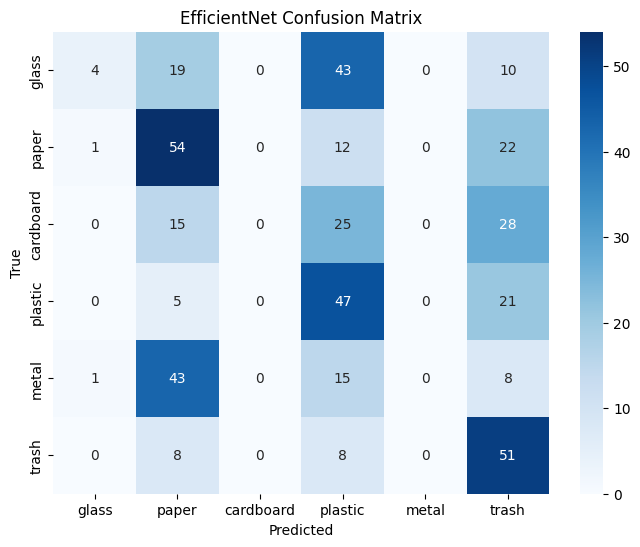

Classification Report:
              precision    recall  f1-score   support

       glass       0.67      0.05      0.10        76
       paper       0.38      0.61      0.46        89
   cardboard       0.00      0.00      0.00        68
     plastic       0.31      0.64      0.42        73
       metal       0.00      0.00      0.00        67
       trash       0.36      0.76      0.49        67

    accuracy                           0.35       440
   macro avg       0.29      0.34      0.25       440
weighted avg       0.30      0.35      0.26       440



In [13]:
# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true_classes_efficient, y_pred_classes_efficient),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('EfficientNet Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print precision, recall, and F1-score for each class
print("Classification Report:")
print(classification_report(y_true_classes_efficient, y_pred_classes_efficient, target_names=classes, zero_division=0))

#**Model Comparison**

In [14]:
test_precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
test_recall = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

test_precision_efficient = precision_score(y_true_classes_efficient, y_pred_classes_efficient, average='weighted', zero_division=0)
test_recall_efficient = recall_score(y_true_classes_efficient, y_pred_classes_efficient, average='weighted', zero_division=0)

comparison_data = {
    'Model': ['MobileNetV2', 'EfficientNetV2B0'],
    'Accuracy': [test_acc*100, test_acc_efficient*100],
    'Precision': [test_precision, test_precision_efficient],
    'Recall': [test_recall, test_recall_efficient]
}

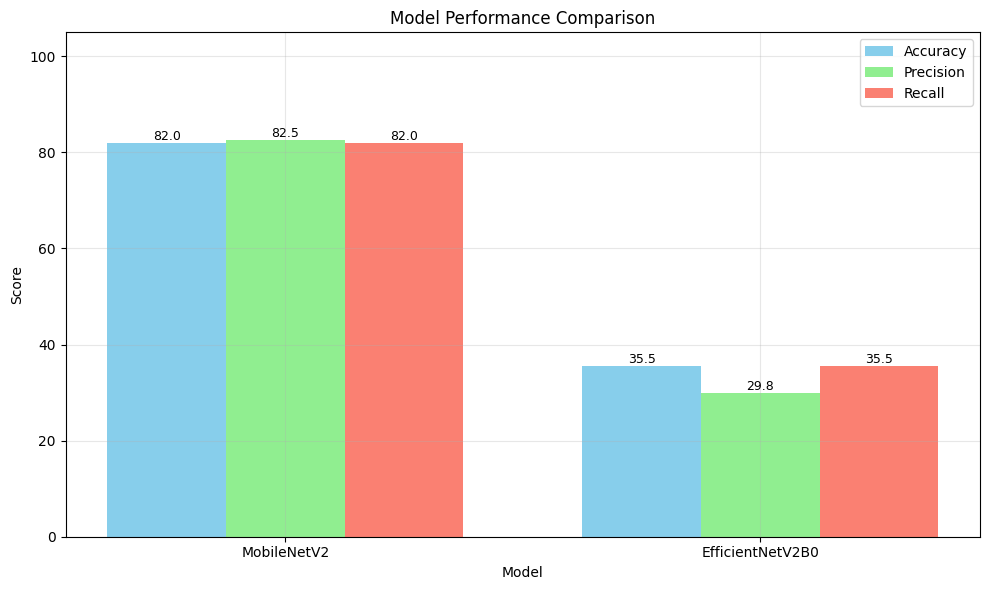

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_data['Model']))
width = 0.25

bars1 = ax.bar(x - width, comparison_data['Accuracy'], width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x, [p*100 for p in comparison_data['Precision']], width, label='Precision', color='lightgreen')
bars3 = ax.bar(x + width, [r*100 for r in comparison_data['Recall']], width, label='Recall', color='salmon')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Model'])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()



> MobileNetV2 performs better with 82% accuracy

